# Setting up environment

In [1]:
!git config --global user.email "Seifomara9@gmail.com"
!git config --global user.name "Seifomara"

In [9]:
!git clone https://github.com/Seifomara/ML-fundamentals-2026.git

Cloning into 'ML-fundamentals-2026'...


In [4]:
from google.colab import userdata
token = userdata.get('PAT')

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Identifying the prediction target






Our target variable = "y"

"y" is our binary ("yes"/"no") target variable our model will try to predict as the campaigns obvjective is predicting subscribitions before/during campaign.





Superficially valid target variables


*   poutcome (outcome of the previous marketing campaign): should not be our target variable as we're trying to predict current campaign not past.
*   duration (last contact duration, in seconds): should not be our target variable as we're trying to predict wether customer subscribes and not how long the call will last

# Data loading and exploration

In [14]:
df = pd.read_csv("bank-additional.csv",sep=';')

In [15]:
df.shape #number of rows, columns

(4119, 21)

In [31]:
df.dtypes #column types

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [17]:
df.describe()  # summary statistics for numerical columns


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [19]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [20]:
df['y'].value_counts()

,count
y,
no,3668
yes,451


Theres a significant class inbalance in our target variable with 89.05% "no"

In [22]:
df.isnull().sum()  # explicit missing values (NaN)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [26]:
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns")

job: 39 unknowns
marital: 11 unknowns
education: 167 unknowns
default: 803 unknowns
housing: 105 unknowns
loan: 105 unknowns


Missing values:


* job: 39 unknowns
* marital: 11 unknowns
* education: 167 unknowns
* default: 803 unknowns
* housing: 105 unknowns
* loan: 105 unknowns



**numerical variables distribution**

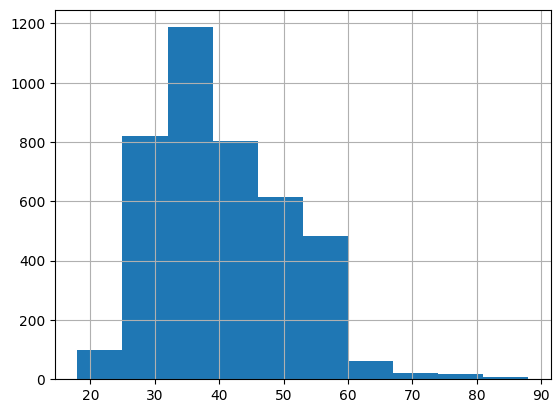

In [28]:
df['age'].hist()
plt.show()

the distribution of numerical variable age is bell shaped, right-skewed with a long tail to the right going up to 90. Which suggests we would need to feature sclaing

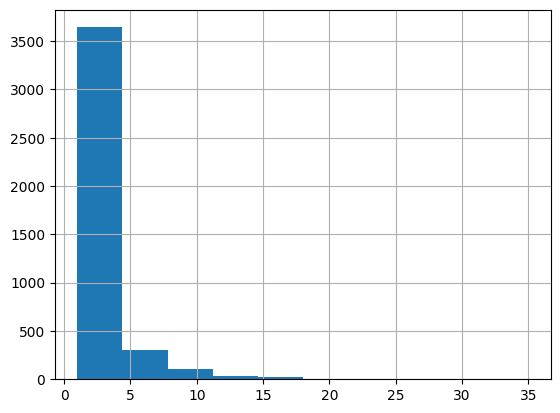

In [29]:
df['campaign'].hist()
plt.show()

In [30]:
df['campaign'].max()

35

the distribution of numerical variable campaign is concentrated between 1 and 4. which means most people were contacted from 1-4 times however it is also very right-skewed with extreme outliers going up to 35. Someone was contacted 35 times.

**categorical variables distribution**



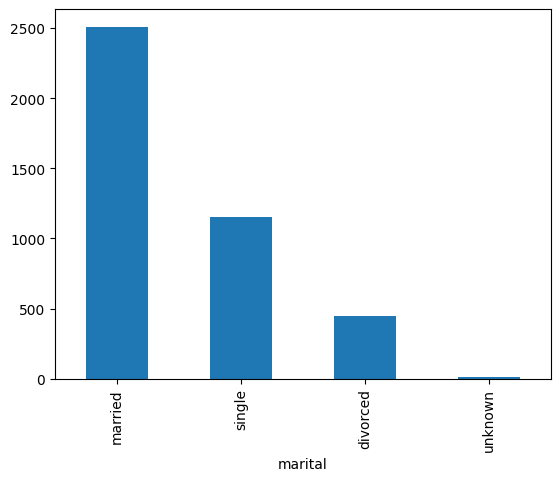

In [32]:
df['marital'].value_counts().plot(kind='bar')
plt.show()

most of our individuals contacted are married

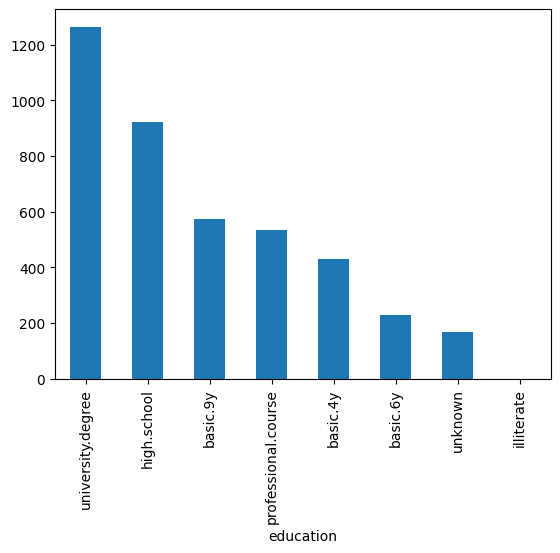

In [33]:
df['education'].value_counts().plot(kind='bar')
plt.show()

most common degree is university degree, with the next most common is highschool. this variable is an ordinal variable (categories with a meaningful order). Theres also unknown values which represents missing values.

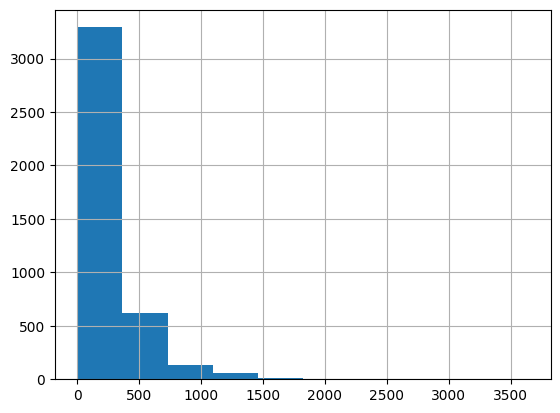

In [36]:
df['duration'].hist()
plt.show()

a variable that will require special attention is "duration" as its right-skewed, and its availibilty is at prediction time

# Data Splitting

I will split the data 60/20/20. Which gives 2471 rows for training, 824 rows for validating, and 824 rows for testing.

We will also need to stratify to solve our class inbalance issue

In [39]:
X = df.drop(columns=['y'])
y = df['y']

In [43]:
#test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

#training and validation
X_train, X_val, y_train, y_val = train_test_split(
X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full,
)

In [46]:
#verify split
print(X_train.shape, X_val.shape, X_test.shape)

/bin/bash: -c: line 1: syntax error near unexpected token `X_train.shape,'
/bin/bash: -c: line 1: `print(X_train.shape, X_val.shape, X_test.shape)'


In [45]:
#verify stratify
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


We split our data at this stage of the pipeline, before handling missing values as if we did handle missing values, we would be using information from our test set. Also scaling before splitting leaks info like mean and std.

In [56]:
!find /content -name "*.ipynb"


/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Recursion Lab - Algorithms & Data Structures.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Divide and Conquer Lab.ipynb
/content/drive/MyDrive/Colab Notebooks/Hash Tables - Algorithms & Data Structures.ipynb
/content/drive/MyDrive/Colab Notebooks/Algorithms and Data Structures LAB OOP.ipynb
/content/drive/MyDrive/Colab Notebooks/PCA Individual Assignment.ipynb
/content/drive/MyDrive/Colab Notebooks/Trees_PQs_lab (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Balanced_trees_LAB.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Multiple Linear Regression - Assignment Template.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/U

In [57]:
!cp /content/drive/MyDrive/Colab Notebooks/assignment_1_<Seif_Omara_[Omara]>.ipynb

/bin/bash: line 1: Seif_Omara_[Omara]: No such file or directory


In [53]:
!git add assignment_1_Seif_Omara.ipynb
!git commit -m "Implemented until Data Splitting: 60/20/20 stratified split"
!git pull
!git push

fatal: pathspec 'assignment_1_Seif_Omara.ipynb' did not match any files
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
Your configuration specifies to merge with the ref 'refs/heads/main'
from the remote, but no such ref was fetched.
error: src refspec refs/heads/main does not match any
error: failed to push some refs to 'https://github.com/Seifomara/ML-fundamentals-2026.git'


# Managing missing values

In [47]:
df.isnull().sum()  #(NaN)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [48]:
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns")

job: 39 unknowns
marital: 11 unknowns
education: 167 unknowns
default: 803 unknowns
housing: 105 unknowns
loan: 105 unknowns
